**kMeans Clustering**

In dieser Aufgabe experimentieren wir mit dem kMeans Clusteringalgorithmus. Dazu erzeugen wir und erst einige künstliche Daten, wofür folgende Methoden verwendet werden können:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create example data - method 1
def createData():
    
    # training
    np.random.seed(42) 
    # ...center
    mu = [0, 0]
    sigma = [[1, 0], [0, 1]]
    trainX = np.random.multivariate_normal(mu, sigma, 100)
    trainY = np.ones([trainX.shape[0], 1])
    # ...left|bottom|right
    mu = [-5, 0]
    sigma = [[1, 0], [0, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    mu = [5, 0]
    sigma = [[1, 0], [0, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    mu = [0, -4]
    sigma = [[5, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    
    # testing
    # ...generate test points on grid
    steps = 0.1
    x = np.arange(-8, 8, steps)
    X1, X2 = np.meshgrid(x, x)
    testX = np.block( [ np.reshape(X1, [X1.shape[0]*X1.shape[1], 1] ), 
                        np.reshape(X2, [X1.shape[0]*X1.shape[1], 1] ) ])
    
    return (trainX, trainY, testX)


# create example data - method 2
def createData2():
    
    np.random.seed(42) 
    numSamples = 50
    # ...cluster 1
    mu = [-4.5, 2]
    sigma = [[1, 0], [0, 4]]
    trainX = np.random.multivariate_normal(mu, sigma, numSamples)
    trainY = 1*np.ones([numSamples, 1])
    # ...cluster 2
    mu = [0, 0]
    sigma = [[1, 0], [0, 2]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [2*np.ones([numSamples, 1])]])
    #...cluster 3
    mu = [5, -4]
    sigma = [[3, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [3*np.ones([numSamples, 1])]])
    # ...cluster 4
    mu = [6, 6]
    sigma = [[3, 1], [1, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [4*np.ones([numSamples, 1])]])
    
    return  (trainX, trainY)



* Erzeugen Sie zunächst die beiden Datensets. Verwenden Sie dann eine geeignete Visualisierungstechnik aus der Vorlesung, um sich die (zweidimensionalen) Daten anzusehen.

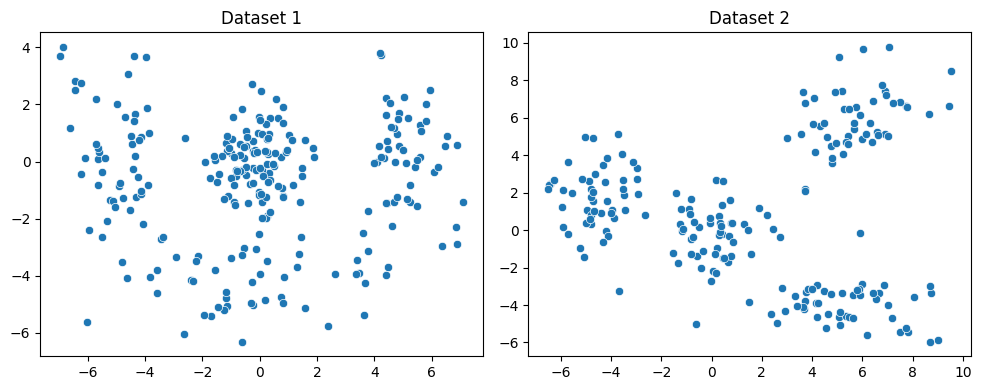

In [8]:
# TODO
# create training and test data
(trainX1, trainY1, testX1) = createData()
(trainX2, trainY2) = createData2()
 
# visualize using a scatterplot
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.scatterplot(x=trainX1[:,0], y=trainX1[:,1], ax=axes[0])
axes[0].set_title("Dataset 1")

sns.scatterplot(x=trainX2[:,0], y=trainX2[:,1], ax=axes[1])
axes[1].set_title("Dataset 2")

plt.tight_layout()


* Verwenden Sie die kMeans Implementierung der scikit-learn Library, um die mit createData (siehe oben) erzeugten Daten in Cluster einzuteilen. Dabei ist natürlich zu beachten, dass nur die Features, nicht aber die Labels verwendet werden. Überlegen Sie dann, wie eine geeignete Parametrierung des kMeans aussehen kann, experimentieren Sie mit geeigneten Settings.
* Visualisieren Sie die erhaltenen Cluster, indem Sie die Punkte nach Clusterzugehörigkeit gefärbt plotten!

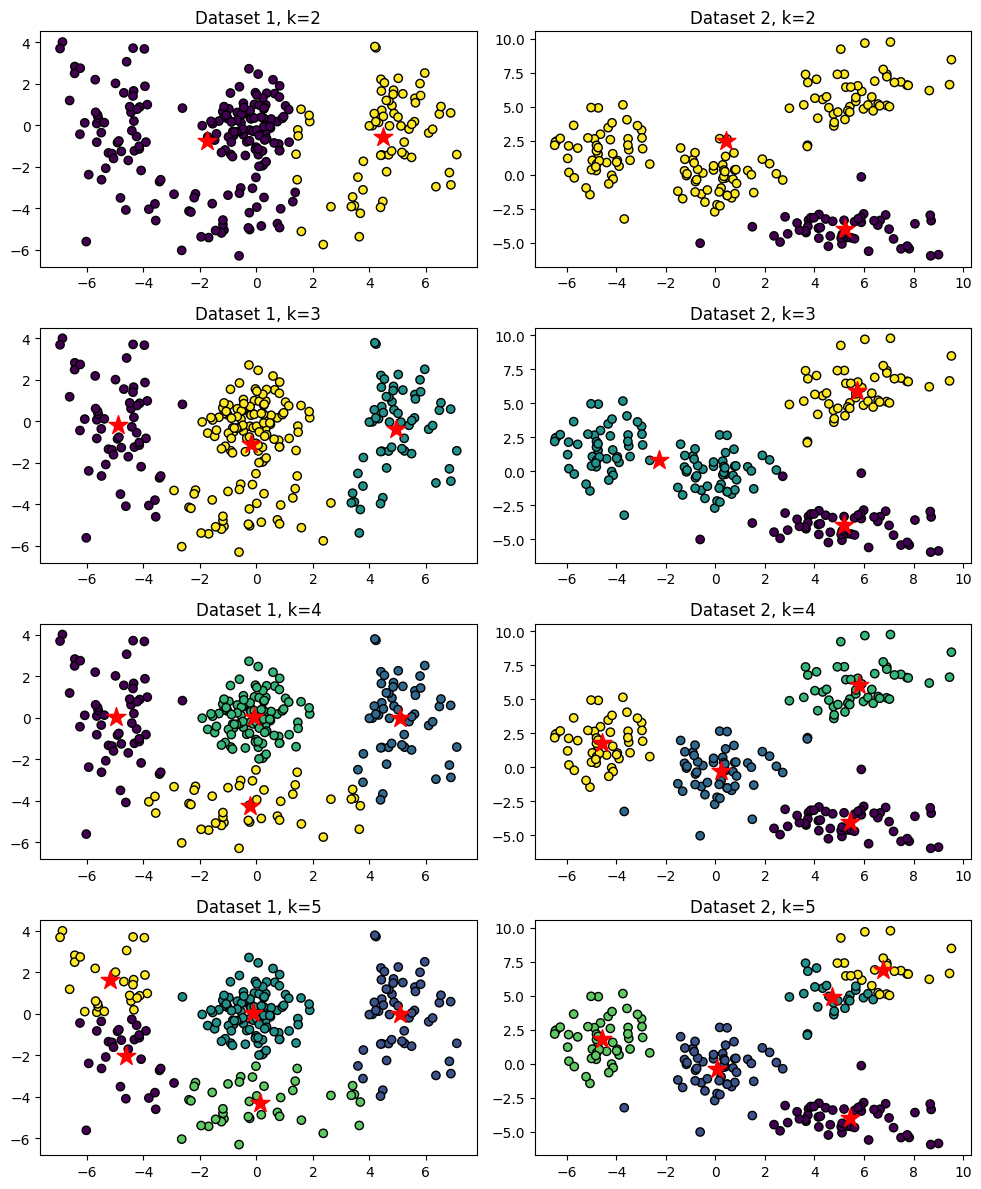

In [12]:
# TODO
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2, 6)

datasets = [
    (trainX1, "Dataset 1"),
    (trainX2, "Dataset 2")
]

fig, axes = plt.subplots(len(k_values), 2, figsize=(10, 12))

for row, k in enumerate(k_values):

    for col, (trainX, title) in enumerate(datasets):

        ax = axes[row, col]

        # KMeans
        kmeans = KMeans(n_clusters=k, random_state=0).fit(trainX)
        idx = kmeans.labels_
        cluster_centers = kmeans.cluster_centers_

        # Punkte
        ax.scatter(trainX[:,0], trainX[:,1],
                   c=idx, cmap="viridis", edgecolor="k")

        # Zentren
        ax.scatter(cluster_centers[:,0], cluster_centers[:,1],
                   marker="*", s=200, color="red")

        ax.set_title(f"{title}, k={k}")

plt.tight_layout()
plt.show()

* Evaluieren Sie dann die Resultate, indem Sie z.B. die Purity (unter der Nutzung der wahren Labels in trainY) oder den Davies-Boulding oder Silhouette Score berechnen. Experimentieren Sie mit verschiedenen k und diskutieren Sie die Ergebnisse.


Dataset 1
k= 2 | Davies-Bouldin=0.827 | Silhouette=0.441 | Purity=0.628
k= 3 | Davies-Bouldin=0.831 | Silhouette=0.468 | Purity=0.852
k= 4 | Davies-Bouldin=0.663 | Silhouette=0.527 | Purity=0.992
k= 5 | Davies-Bouldin=0.703 | Silhouette=0.516 | Purity=0.996
k= 6 | Davies-Bouldin=0.873 | Silhouette=0.385 | Purity=0.988
k= 7 | Davies-Bouldin=0.851 | Silhouette=0.400 | Purity=0.988
k= 8 | Davies-Bouldin=0.860 | Silhouette=0.385 | Purity=0.984
k= 9 | Davies-Bouldin=0.860 | Silhouette=0.371 | Purity=0.988
k=10 | Davies-Bouldin=0.947 | Silhouette=0.350 | Purity=0.988

Dataset 2
k= 2 | Davies-Bouldin=0.839 | Silhouette=0.398 | Purity=0.500
k= 3 | Davies-Bouldin=0.534 | Silhouette=0.606 | Purity=0.750
k= 4 | Davies-Bouldin=0.557 | Silhouette=0.597 | Purity=0.975
k= 5 | Davies-Bouldin=0.754 | Silhouette=0.516 | Purity=0.985
k= 6 | Davies-Bouldin=0.828 | Silhouette=0.461 | Purity=0.990
k= 7 | Davies-Bouldin=0.824 | Silhouette=0.461 | Purity=0.990
k= 8 | Davies-Bouldin=0.891 | Silhouette=0.415 |

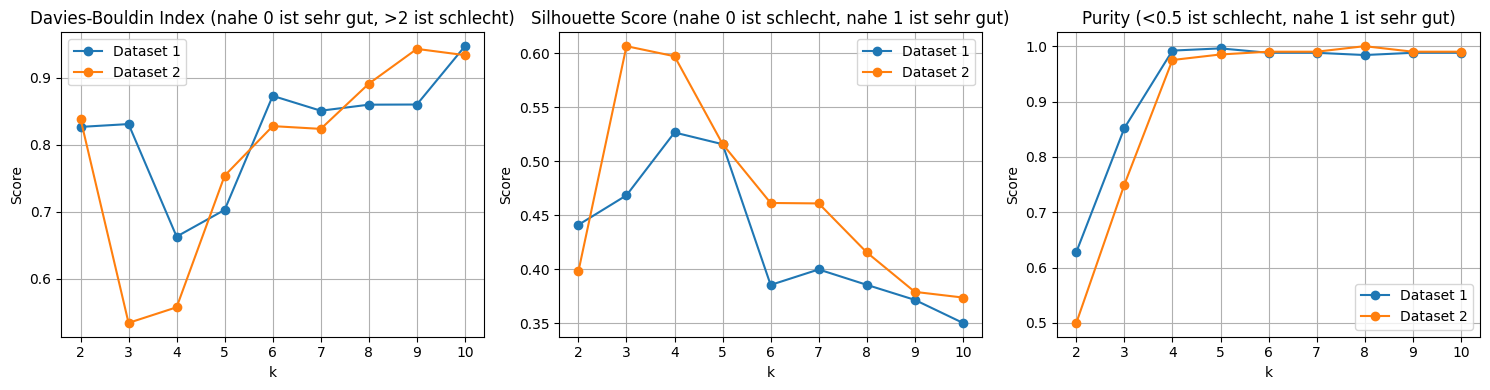

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

# k-Bereich
k_values = range(2, 11)

datasets = [
    (trainX1, trainY1, "Dataset 1"),
    (trainX2, trainY2, "Dataset 2")
]

results = {}

for trainX, trainY, name in datasets:
    db_scores = []
    silhouette_scores = []
    purity_scores = []

    for k in k_values:
        # KMeans fitten
        kmeans = KMeans(n_clusters=k, random_state=0).fit(trainX)
        idx = kmeans.labels_

        # Davies-Bouldin
        db = davies_bouldin_score(trainX, idx)
        db_scores.append(db)

        # Silhouette
        sc = silhouette_score(trainX, idx, metric="euclidean")
        silhouette_scores.append(sc)

        # Purity
        nominator = 0
        for i in range(k):
            labels_in_cluster_i = trainY[idx == i].ravel()
            if labels_in_cluster_i.size > 0:
                _, counts = np.unique(labels_in_cluster_i, return_counts=True)
                nominator += np.max(counts)

        purity = nominator / idx.shape[0]
        purity_scores.append(purity)

    results[name] = {
        "db": db_scores,
        "silhouette": silhouette_scores,
        "purity": purity_scores
    }

    # Konsolenausgabe
    print(f"\n{name}")
    for k, db, sc, purity in zip(k_values, db_scores, silhouette_scores, purity_scores):
        print(
            f"k={k:2d} | "
            f"Davies-Bouldin={db:.3f} | "
            f"Silhouette={sc:.3f} | "
            f"Purity={purity:.3f}"
        )

# Plot der Scores über k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, scores in results.items():
    axes[0].plot(list(k_values), scores["db"], marker="o", label=name)
    axes[1].plot(list(k_values), scores["silhouette"], marker="o", label=name)
    axes[2].plot(list(k_values), scores["purity"], marker="o", label=name)

axes[0].set_title("Davies-Bouldin Index (nahe 0 ist sehr gut, >2 ist schlecht)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Score")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Silhouette Score (nahe 0 ist schlecht, nahe 1 ist sehr gut)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

axes[2].set_title("Purity (<0.5 ist schlecht, nahe 1 ist sehr gut)")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Score")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()